In [1]:
# Packages 
import yfinance as yf
from pprint import pprint 
import pandas as pd 
import seaborn as sns
import plotly.graph_objects as go
import plotly.io as pio
import plotly.express as px
import matplotlib.pyplot as plt 
from datetime import datetime, timedelta, timezone

pio.renderers.default = "browser"   # set once per session
import mplfinance as mpf


# All graphs / functionality should update based on 
SYMBOL = "LINK-USD"

# One Year winow exampl
END_DATE = datetime.now(timezone.utc)
START_DATE = (END_DATE - timedelta(days=365))

print(f"- Symbol: {SYMBOL} \n\n- Start Date: {START_DATE} \n- End Date: {END_DATE}")

- Symbol: LINK-USD 

- Start Date: 2025-03-05 07:54:05.170663+00:00 
- End Date: 2026-03-05 07:54:05.170663+00:00


In [2]:
# Get ticker data
link = yf.Ticker(SYMBOL)

# Get historical market data
hist = link.history(period="max")

hist_df = pd.DataFrame(hist)
hist_df = hist_df.sort_index()
subset_df = hist_df[START_DATE:END_DATE].sort_index(ascending=False)
subset_df.head()

,Open,High,Low,Close,Volume,Dividends,Stock Splits
Date,,,,,,,
2026-03-05 00:00:00+00:00,9.351733,9.371916,9.219783,9.219783,970902720,0.0,0.0
2026-03-04 00:00:00+00:00,8.812367,9.614965,8.700853,9.348465,958769737,0.0,0.0
2026-03-03 00:00:00+00:00,8.948490,9.002707,8.598036,8.812367,759572365,0.0,0.0
2026-03-02 00:00:00+00:00,8.672601,9.217735,8.598518,8.948497,852252201,0.0,0.0
2026-03-01 00:00:00+00:00,8.843731,9.184593,8.554014,8.672350,777710762,0.0,0.0


In [3]:
subset_df.info()

<class 'pandas.DataFrame'>
DatetimeIndex: 365 entries, 2026-03-05 00:00:00+00:00 to 2025-03-06 00:00:00+00:00
Data columns (total 7 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Open          365 non-null    float64
 1   High          365 non-null    float64
 2   Low           365 non-null    float64
 3   Close         365 non-null    float64
 4   Volume        365 non-null    int64  
 5   Dividends     365 non-null    float64
 6   Stock Splits  365 non-null    float64
dtypes: float64(6), int64(1)
memory usage: 22.8 KB


In [4]:
subset_df.describe()

,Open,High,Low,Close,Volume,Dividends,Stock Splits
count,365.000000,365.000000,365.000000,365.000000,3.650000e+02,365.0,365.0
mean,15.480136,15.956182,14.960645,15.460325,7.072701e+08,0.0,0.0
std,4.252092,4.407031,4.106176,4.264373,5.000771e+08,0.0,0.0
min,7.906779,8.326231,7.319640,7.907181,1.533105e+08,0.0,0.0
25%,12.934733,13.268948,12.582278,12.934548,3.589475e+08,0.0,0.0
50%,14.118260,14.485215,13.794673,14.115714,5.799143e+08,0.0,0.0
75%,17.432673,18.214069,16.885569,17.432764,8.690221e+08,0.0,0.0
max,26.746090,27.735258,25.556709,26.746483,3.394108e+09,0.0,0.0


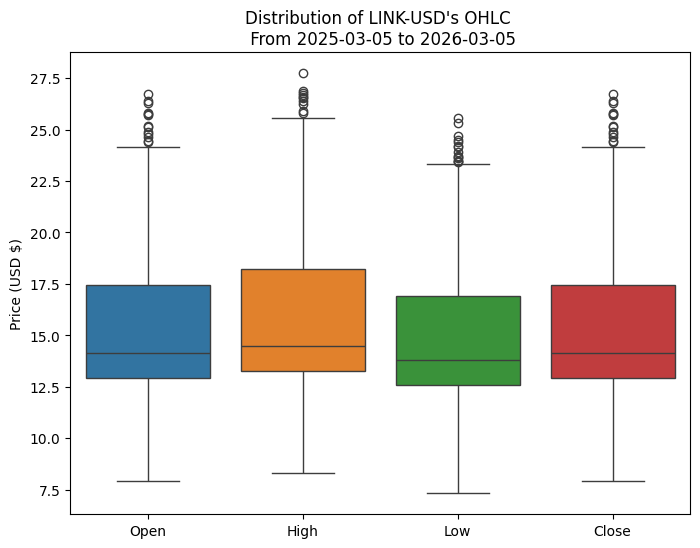

In [5]:
# Create a box plot
c = subset_df.copy()[["Open", "High", "Low", "Close"]]
plt.figure(figsize=(8, 6))
sns.boxplot(c) #
plt.title(f"Distribution of {SYMBOL}'s OHLC \n From {START_DATE.strftime('%Y-%m-%d')} to {END_DATE.strftime('%Y-%m-%d')}")
plt.ylabel("Price (USD $)")
plt.show()

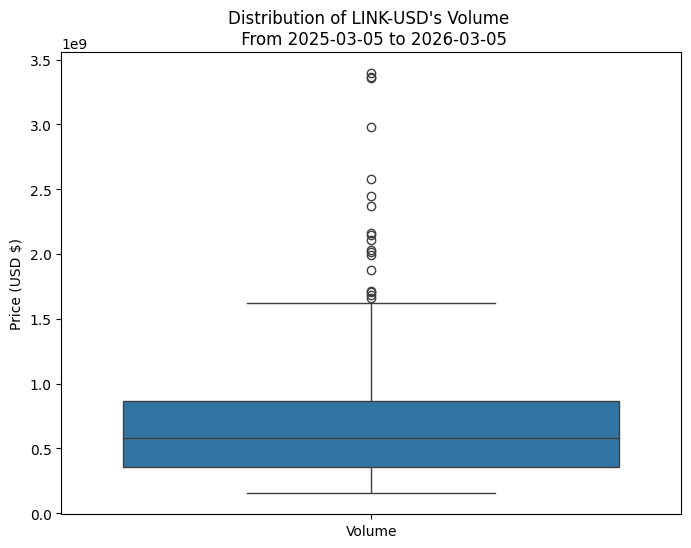

In [6]:
# Create a box plot
c = subset_df.copy()[["Volume"]]
plt.figure(figsize=(8, 6))
sns.boxplot(c) #
plt.title(f"Distribution of {SYMBOL}'s Volume \n From {START_DATE.strftime('%Y-%m-%d')} to {END_DATE.strftime('%Y-%m-%d')}")
plt.ylabel("Price (USD $)")
plt.show()

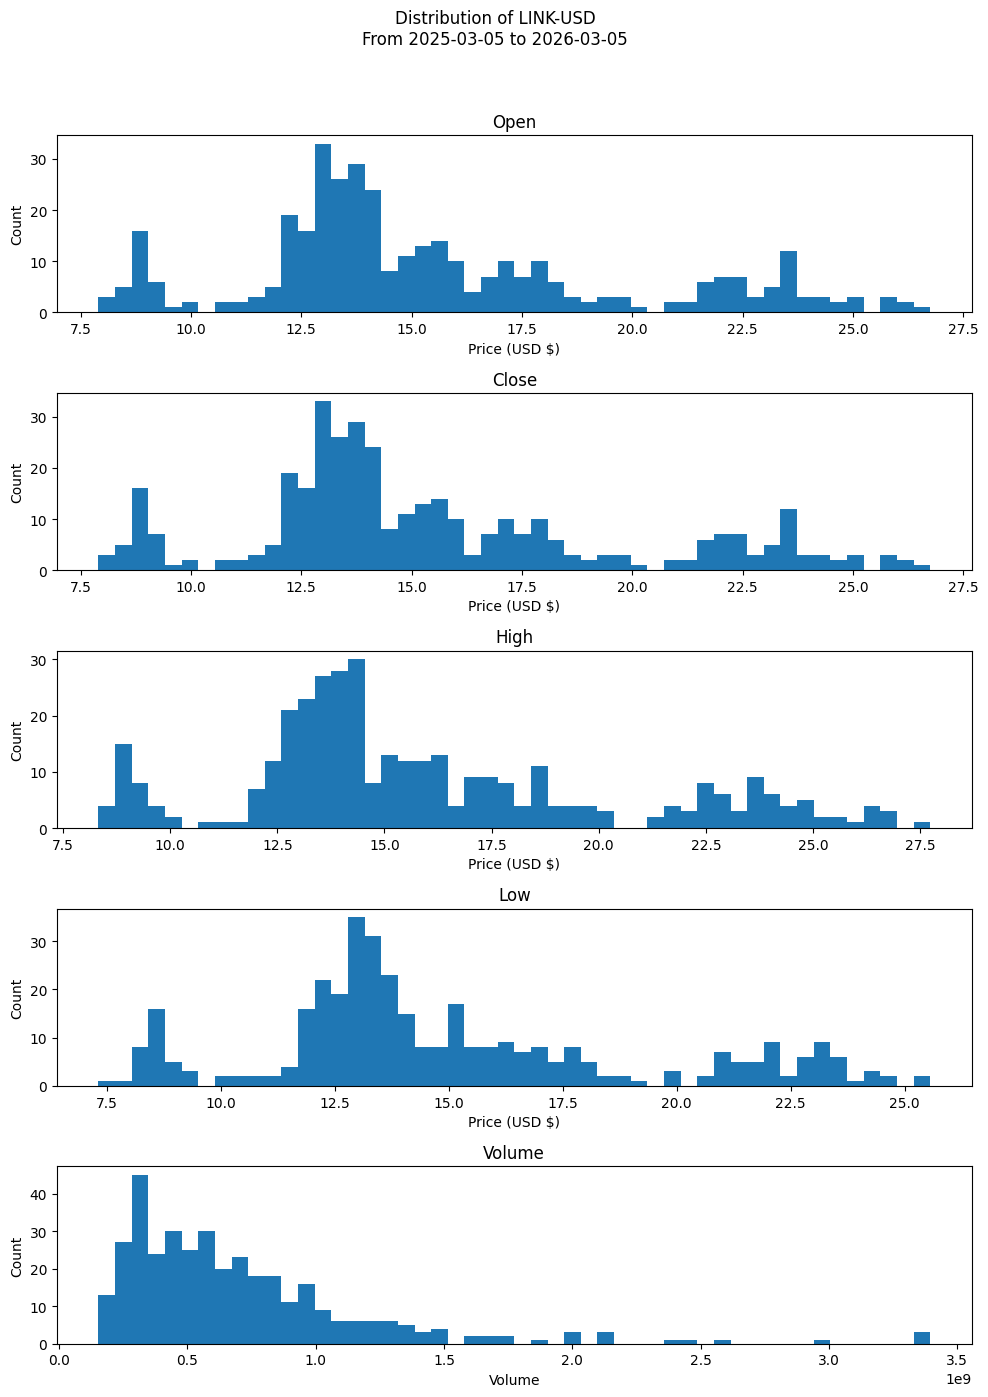

In [7]:
cols = ["Open", "Close", "High", "Low", "Volume"]
c = subset_df[cols].copy()

fig, ax = plt.subplots(nrows=5, ncols=1, figsize=(10, 14), sharex=False)

for i, col in enumerate(cols):
    ax[i].hist(c[col].dropna(), bins=50)
    ax[i].set_title(f"{col}")
    ax[i].set_ylabel("Count")
    ax[i].set_xlabel("Volume" if col == "Volume" else "Price (USD $)")

fig.suptitle(
    f"Distribution of {SYMBOL}\nFrom {START_DATE:%Y-%m-%d} to {END_DATE:%Y-%m-%d}",
    y=0.995
)
plt.tight_layout(rect=[0, 0, 1, 0.97])
plt.show()

# Interactive Candle Stick Graph For LINK-USD

In [8]:
df = hist_df.copy()

fig = go.Figure(data=[go.Candlestick(x=df.index,
                open=df['Open'],
                high=df['High'],
                low=df['Low'],
                close=df['Close'])])

fig.update_layout(title='LINK Interactive Chart', yaxis_title='Price')
fig.show()

# Volume (365 Day Window)

In [9]:
now = datetime.now()
one_year_ago = now - timedelta(days=365)

subset = df.loc['2025-03-05 00:00:00+00:00':'2026-03-05 00:00:00+00:00']
fig = px.bar(subset, x=subset.index, y=subset["Volume"])
fig.show()

# Other Data All time, 52-Week Recent News, and other meta data

In [10]:
t = yf.Ticker(SYMBOL)
info = t.info          # big dict (varies by ticker)
fast = t.fast_info     # smaller/faster quote-like fields

print('=' * 50 )
pprint(sorted(info.keys())[:40])   # inspect what you actually get
print('=' * 50 )
pprint(type(fast))

['allTimeHigh',
 'allTimeLow',
 'averageDailyVolume10Day',
 'averageDailyVolume3Month',
 'averageVolume',
 'averageVolume10days',
 'circulatingSupply',
 'coinImageUrl',
 'coinMarketCapLink',
 'companyOfficers',
 'corporateActions',
 'cryptoTradeable',
 'currency',
 'customPriceAlertConfidence',
 'dayHigh',
 'dayLow',
 'description',
 'esgPopulated',
 'exchange',
 'exchangeDataDelayedBy',
 'exchangeTimezoneName',
 'exchangeTimezoneShortName',
 'executiveTeam',
 'fiftyDayAverage',
 'fiftyDayAverageChange',
 'fiftyDayAverageChangePercent',
 'fiftyTwoWeekChangePercent',
 'fiftyTwoWeekHigh',
 'fiftyTwoWeekHighChange',
 'fiftyTwoWeekHighChangePercent',
 'fiftyTwoWeekLow',
 'fiftyTwoWeekLowChange',
 'fiftyTwoWeekLowChangePercent',
 'fiftyTwoWeekRange',
 'firstTradeDateMilliseconds',
 'fromCurrency',
 'fullExchangeName',
 'fullyDilutedValue',
 'gmtOffSetMilliseconds',
 'hasPrePostMarketData']
<class 'yfinance.scrapers.quote.FastInfo'>


In [11]:
news1 = t.get_news(count=20, tab="news")  
news2 = yf.Search("Chainlink", news_count=20).news

In [ ]:
print('=' * 50)
print(f'       {len(news1)} Total Articles Found from News1!!')
print('=' * 50 + '\n')

for news in news1:
    url = news.get('content').get('clickThroughUrl').get('url')
    title = news.get('content').get('title')
    pubDate = news.get('content').get('pubDate')
    print(f"Title: {title} \n\t- pubDate: {pubDate} \n\t- url: {url}\n")


       20 Total Articles Found from News2!!

Title: Trump Family-Linked Stablecoin Unveils Live Reserve Tracker After De-Pegging Scare 
	- pubDate: 2026-02-28T11:43:44Z 
	- url: https://finance.yahoo.com/news/trump-family-linked-stablecoin-unveils-114344346.html

Title: Hester Peirce Predicts 'Great Things' After Ex-Chainlink Executive Joins SEC Crypto Task Force As Chief Counsel 
	- pubDate: 2026-02-27T18:31:08Z 
	- url: https://finance.yahoo.com/news/hester-peirce-predicts-great-things-183108450.html

Title: Chainlink Price Surges: What’s Behind Today’s LINK Rally? 
	- pubDate: 2026-02-26T13:36:11Z 
	- url: https://finance.yahoo.com/news/chainlink-price-surges-behind-today-133611685.html

Title: LINK Price Is Finally Up: Chainlink Breaking Out? 
	- pubDate: 2026-02-26T13:27:55Z 
	- url: https://finance.yahoo.com/news/price-finally-chainlink-breaking-132755555.html

Title: Ethereum Pops 11%, but Still Can’t Break Free as Holders Sell at a Loss 
	- pubDate: 2026-02-26T12:00:00Z 
	- url

In [ ]:
print('=' * 50)
print(f'       {len(news2)} Total Articles Found from News2!!')
print('=' * 50 + '\n')
for news in news2:
    title = news.get('title')
    publisher = news.get('publisher')
    link = news.get('link')

    print(f"Title: {title}\n\t- Publisher: {publisher}\n\t Link: {link}\n")


8 Total Articles Found from News2!!

Title: JPMorgan Identifies 8 CLARITY Act Catalysts—And Altcoins Like XRP Could Benefit
	- Publisher: Benzinga
	 Link: https://finance.yahoo.com/news/jpmorgan-identifies-8-clarity-act-190019335.html

Title: Decentralized AI Company 0G And AIverse Introduce The First Web 4.0 Marketplace – Where AI Agents Own, Trade, and Evolve On-Chain
	- Publisher: GlobeNewswire
	 Link: https://finance.yahoo.com/news/decentralized-ai-company-0g-aiverse-150000758.html

Title: Trump vs. The Banks: Is the Clarity Act a Game Changer?
	- Publisher: 99bitcoins
	 Link: https://finance.yahoo.com/m/b7cee34d-30a9-31ab-a7ff-75f81c54d82b/trump-vs.-the-banks%3A-is-the.html

Title: Crypto Funds Record $1B Weekly Inflows, Ending $4B Outflow Streak
	- Publisher: GuruFocus.com
	 Link: https://finance.yahoo.com/news/crypto-funds-record-1b-weekly-151617661.html

Title: Trade Everything, Always: RWA Perpification as the Missing Layer Between DeFi and Wall Street
	- Publisher: BeInCrypto

# Live Websocket Data 

In [14]:
t.live()

Connected to WebSocket.
Subscribed to symbols: ['LINK-USD']
Listening for messages...
Received keyboard interrupt.
WebSocket connection closed.
